In [1]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.1 MB/s eta 0:00:00


In [2]:
import os, json, time, warnings, logging
from pathlib import Path
from datetime import datetime
from collections import defaultdict
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
log = logging.getLogger(__name__)

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW                        

from transformers import (
    DistilBertTokenizerFast,                          # fast tokenizer
    DistilBertForSequenceClassification,
    DistilBertConfig,
    get_cosine_schedule_with_warmup
)
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import joblib, mlflow, mlflow.pytorch
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = True   # speeds up fixed-size inputs

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu') #optimizes GPU performance  
N_GPUS = torch.cuda.device_count()

print('=' * 55)
print('  DistilBERT Sentiment — Environment Check')
print('=' * 55)
print(f'  Device    : {DEVICE}')
print(f'  GPUs      : {N_GPUS}')
if torch.cuda.is_available():
    print(f'  GPU name  : {torch.cuda.get_device_name(0)}')
    print(f'  GPU VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'  PyTorch   : {torch.__version__}')
print(f'  MLflow    : {mlflow.__version__}')
print(f'  Started   : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print("done")

2026-05-12 22:40:17,848 | INFO | NumExpr defaulting to 4 threads.


  DistilBERT Sentiment — Environment Check
  Device    : cuda
  GPUs      : 2
  GPU name  : Tesla T4
  GPU VRAM  : 15.6 GB
  PyTorch   : 2.10.0+cu128
  MLflow    : 3.12.0
  Started   : 2026-05-12 22:40:46
done


In [3]:
from pathlib import Path

input_dir = Path('/kaggle/input')
for f in sorted(input_dir.rglob('*.csv')):
    print(f)

/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Alibaba.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Aliexpress.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Amazon shopping.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Daraz Online Shopping App.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Flipkart.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Lazada.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Meesho.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Myntra.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Shein.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Snapdeal.csv
/kaggle/input/datasets/bennjimatakwa/ecommerce-customerbehavior-dl/csv/Walmart.csv
/kaggle/input/notebooks/bennjimatakwa/datamerge-01/data/proce

##  Directory & Path Configuration

Defines project root and all key subdirectories relative to it:
- `DATA_DIR` — preprocessed CSVs (train / val / test)
- `MODEL_DIR` — saved model checkpoints and class weights
- `LOG_DIR` — MLflow experiment tracking logs
- `FIG_DIR` — output figures and plots

Creates any missing directories automatically with `mkdir(parents=True, exist_ok=True)`.

In [4]:
from pathlib import Path

candidates = sorted(Path('/kaggle/input').rglob('train.csv'))
candidates = [p for p in candidates if 'processed' in str(p)]
assert candidates, "train.csv not found in /kaggle/input — check your input sources!"
DATA_DIR = candidates[0].parent
print(f"✅ DATA_DIR: {DATA_DIR}")

# All outputs must go inside /kaggle/working
MODEL_DIR = Path('/kaggle/working/models')
LOG_DIR   = Path('/kaggle/working/mlflow_runs')
FIG_DIR   = Path('/kaggle/working/outputs/figures')

# Create output folders if they don't exist
for d in [MODEL_DIR, LOG_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameter Configuration ───────────────────────────
CFG = {
    # Model
    'model_name'         : 'distilbert-base-uncased',
    'num_classes'        : 3,
    'max_len'            : 128,
    'dropout'            : 0.4,

    # Training
    'epochs'             : 3,
    'batch_size'         : 64,
    'accumulation_steps' : 1,
    'lr'                 : 1e-5,
    'weight_decay'       : 0.01,
    'warmup_ratio'       : 0.1,
    'max_grad_norm'      : 1.0,
    'use_amp'            : torch.cuda.is_available(),  # FP16 on GPU only

    # Data
    'train_sample'       : 15000,
    'num_workers'        : 2,
    'random_state'       : SEED,

    # Labels
    'label_names'        : ['negative', 'neutral', 'positive'],
    'id_to_label'        : {0: 'negative', 1: 'neutral', 2: 'positive'},
    'label_map'          : {'negative': 0, 'neutral': 1, 'positive': 2},

    # MLflow
    'experiment_name'    : '01_DistilBERT_Sentiment_Analysis',
    'run_name'           : 'distilbert-base-uncased-v1'
}

print('Configuration loaded:')
for k, v in CFG.items():
    if not isinstance(v, dict):
        print(f'  {k:<24}: {v}')

✅ DATA_DIR: /kaggle/input/notebooks/bennjimatakwa/textprocessing-feature-03/data/processed
Configuration loaded:
  model_name              : distilbert-base-uncased
  num_classes             : 3
  max_len                 : 128
  dropout                 : 0.4
  epochs                  : 3
  batch_size              : 64
  accumulation_steps      : 1
  lr                      : 1e-05
  weight_decay            : 0.01
  warmup_ratio            : 0.1
  max_grad_norm           : 1.0
  use_amp                 : True
  train_sample            : 15000
  num_workers             : 2
  random_state            : 42
  label_names             : ['negative', 'neutral', 'positive']
  experiment_name         : 01_DistilBERT_Sentiment_Analysis
  run_name                : distilbert-base-uncased-v1


# 3. Data Loading
Load train.csv / val.csv / test.csv from notebook 02
Load class_weights.pkl for weighted CrossEntropyLoss
Assert all splits have clean_content and sentiment_id
Print split sizes and per-class distribution

In [5]:
# Train / validation /test 
train_df = pd.read_csv(DATA_DIR / 'train.csv')
val_df   = pd.read_csv(DATA_DIR / 'val.csv')
test_df  = pd.read_csv(DATA_DIR / 'test.csv')

from sklearn.utils.class_weight import compute_class_weight
classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['sentiment_id']
)
class_weights = weights.astype(np.float32)
joblib.dump(class_weights, MODEL_DIR / 'class_weights.pkl')
# Sample 15k balanced from train — 5000 per sentiment class
n_per_class = CFG['train_sample'] // 3
min_class   = train_df['sentiment'].value_counts().min()
n_per_class = min(n_per_class, min_class)

train_small = (
    train_df.groupby('sentiment', group_keys=False)
    .apply(lambda x: x.sample(n=n_per_class, random_state=SEED))
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print(f'Training subset : {len(train_small):,} rows ({n_per_class:,} per class)')
print(f'Val             : {len(val_df):,} rows')
print(f'Test            : {len(test_df):,} rows')
print(f'\nTrain class distribution:')
print(train_small['sentiment'].value_counts().to_string())
print(f'\nClass weights for CrossEntropyLoss:')
for i, (name, w) in enumerate(zip(CFG['label_names'], class_weights)):
    print(f'  [{i}] {name:<10}: {w:.4f}')

Training subset : 15,000 rows (5,000 per class)
Val             : 9,751 rows
Test            : 18,747 rows

Train class distribution:
sentiment
positive    5000
neutral     5000
negative    5000

Class weights for CrossEntropyLoss:
  [0] negative  : 1.0075
  [1] neutral   : 0.9806
  [2] positive  : 1.0124


# Tokenization

2026-05-12 22:40:48,434 | INFO | Loading tokenizer: distilbert-base-uncased
2026-05-12 22:40:48,607 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-05-12 22:40:48,675 | INFO | HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

2026-05-12 22:40:48,752 | INFO | HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-05-12 22:40:48,814 | INFO | HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-05-12 22:40:48,879 | INFO | HTTP Request: GET https://huggingface.co/api/models/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
2026-05-12 22:40:48,942 | INFO | HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-05-12 22:40:49,007 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/vocab.txt "HTTP/1.1 200 OK"
2026-05-12 22:40:49,008 | WARNING | Warning: You are sending unauthenticated requests

vocab.txt: 0.00B [00:00, ?B/s]

2026-05-12 22:40:49,184 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"
2026-05-12 22:40:49,278 | INFO | HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/tokenizer.json "HTTP/1.1 200 OK"


tokenizer.json: 0.00B [00:00, ?B/s]

2026-05-12 22:40:49,397 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/added_tokens.json "HTTP/1.1 404 Not Found"
2026-05-12 22:40:49,462 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/special_tokens_map.json "HTTP/1.1 404 Not Found"
2026-05-12 22:40:49,526 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"


Tokenizing sample:   0%|          | 0/2000 [00:00<?, ?it/s]

Token stats  : mean=22.3 | median=18.0 | 95th=54.0
max_len=128 covers 100.0% of reviews


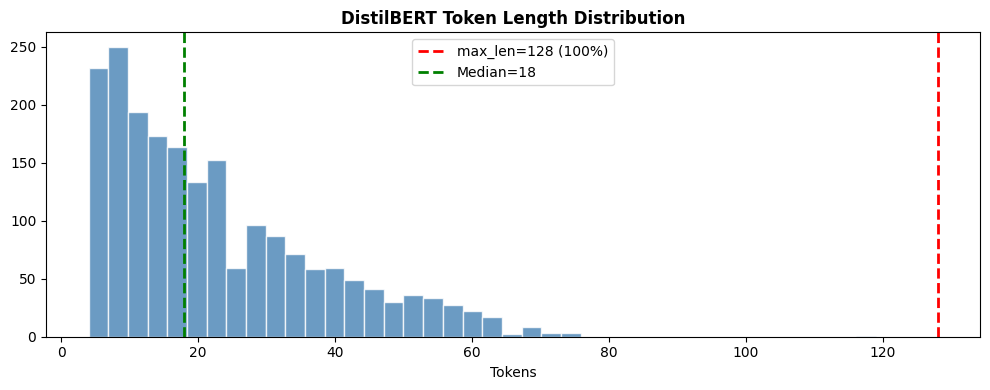

In [6]:
log.info(f'Loading tokenizer: {CFG["model_name"]}')
tokenizer = DistilBertTokenizerFast.from_pretrained(CFG['model_name'])

# Analyze token lengths on a sample
sample_texts = train_small['clean_content'].dropna().sample(min(2000, len(train_small)), random_state=SEED)
token_lengths = [
    len(tokenizer.encode(t, add_special_tokens=True, max_length=512, truncation=True))
    for t in tqdm(sample_texts, desc='Tokenizing sample')
]
pct_covered = (np.array(token_lengths) <= CFG['max_len']).mean() * 100

print(f'Token stats  : mean={np.mean(token_lengths):.1f} | median={np.median(token_lengths):.1f} | 95th={np.percentile(token_lengths,95):.1f}')
print(f'max_len={CFG["max_len"]} covers {pct_covered:.1f}% of reviews')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_lengths, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(CFG['max_len'], color='red',   linestyle='--', lw=2, label=f'max_len={CFG["max_len"]} ({pct_covered:.0f}%)')
ax.axvline(np.median(token_lengths), color='green', linestyle='--', lw=2, label=f'Median={np.median(token_lengths):.0f}')
ax.set_title('DistilBERT Token Length Distribution', fontweight='bold')
ax.set_xlabel('Tokens'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR / '03_token_lengths.png', dpi=150); plt.show()

##  Tokenizer Load & Token-Length Analysis

Loads `DistilBertTokenizerFast` (Rust-backed, ~5× faster than the Python tokenizer).

Encodes a 2,000-sample subset to analyse real token lengths:
- Reports mean, median, and 95th-percentile token counts
- Computes what % of reviews fit within `max_len=128`

Saves a histogram (`03_token_lengths.png`) with reference lines for `max_len` and the median,
so you can confirm that truncation has minimal impact on coverage.

# Dataset & DATALOADERS

In [7]:
class ReviewDataset(Dataset):
    """
    PyTorch Dataset for DistilBERT.
    Uses fast tokenizer — significantly faster than standard tokenizer.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx]) if self.texts[idx] else 'empty'
        enc  = self.tokenizer(
            text,
            max_length            = self.max_len,
            padding               = 'max_length',
            truncation            = True,
            return_tensors        = 'pt',
            return_attention_mask = True
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ReviewDataset(train_small['clean_content'].fillna('empty'), train_small['sentiment_id'], tokenizer, CFG['max_len'])
val_dataset   = ReviewDataset(val_df['clean_content'].fillna('empty'),   val_df['sentiment_id'],   tokenizer, CFG['max_len'])
test_dataset  = ReviewDataset(test_df['clean_content'].fillna('empty'),  test_df['sentiment_id'],  tokenizer, CFG['max_len'])

# WeightedRandomSampler — balanced batches per epoch
label_counts   = train_small['sentiment_id'].value_counts().sort_index()
sample_weights = torch.tensor([1.0/label_counts[l] for l in train_small['sentiment_id'].values], dtype=torch.float)
sampler        = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

pin = DEVICE.type == 'cuda'
train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],   sampler=sampler, num_workers=CFG['num_workers'], pin_memory=pin)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size']*2, shuffle=False,  num_workers=CFG['num_workers'], pin_memory=pin)
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size']*2, shuffle=False,  num_workers=CFG['num_workers'], pin_memory=pin)

print(f'Train : {len(train_dataset):,} samples | {len(train_loader):,} batches (batch={CFG["batch_size"]})')
print(f'Val   : {len(val_dataset):,} samples | {len(val_loader):,} batches')
print(f'Test  : {len(test_dataset):,} samples | {len(test_loader):,} batches')

Train : 15,000 samples | 235 batches (batch=64)
Val   : 9,751 samples | 77 batches
Test  : 18,747 samples | 147 batches


# DistilBERTSentimentClassifier

##  Model Architecture — DistilBERTSentimentClassifier

Fine-tuned DistilBERT with a custom classification head.

**Why DistilBERT over BERT?**
- 66M vs 110M parameters → 40% smaller
- ~60% faster inference
- Retains ~97% of BERT's benchmark accuracy

**Head architecture** (replaces the default single linear layer):

In [8]:
class DistilBERTSentimentClassifier(nn.Module):
    """
    DistilBERT fine-tuned for 3-class sentiment.

    Why DistilBERT over BERT?
      - 66M params vs 110M  -> 40% smaller
      - 60% faster inference
      - Retains 97% of BERT accuracy on NLP benchmarks
      - Same vocabulary, same tokenizer format

    Architecture:
      distilbert-base-uncased (6 layers, 768 hidden)
      + classifier head:
        [CLS](768) -> LayerNorm -> Dropout(0.3)
        -> Linear(768->256) -> GELU
        -> Dropout(0.3) -> Linear(256->3)
    """
    def __init__(self, model_name, num_classes, dropout=0.3):
        super().__init__()
        config = DistilBertConfig.from_pretrained(
            model_name,
            num_labels     = num_classes,
            seq_classif_dropout = dropout
        )
        self.distilbert = DistilBertForSequenceClassification.from_pretrained(
            model_name, config=config
        )
        hidden = self.distilbert.config.dim  # 768
        self.distilbert.classifier = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, labels=None):
        return self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

    def get_logits(self, input_ids, attention_mask):
        """Inference only — no loss computed."""
        return self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).logits

log.info(f'Loading {CFG["model_name"]}...')
model = DistilBERTSentimentClassifier(
    CFG['model_name'], CFG['num_classes'], CFG['dropout']
).to(DEVICE)

if N_GPUS > 1:
    model = nn.DataParallel(model)
    log.info(f'Using {N_GPUS} GPUs')

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model    : {CFG["model_name"]} + custom head')
print(f'Total    : {total:,} parameters')
print(f'Trainable: {trainable:,} parameters')
print(f'Head     : 768 -> LayerNorm -> Dropout -> Linear(256) -> GELU -> Dropout -> 3')
print(f'Device   : {DEVICE}')

2026-05-12 22:40:50,505 | INFO | Loading distilbert-base-uncased...
2026-05-12 22:40:50,576 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-05-12 22:40:50,640 | INFO | HTTP Request: GET https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

2026-05-12 22:40:50,998 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-05-12 22:40:51,064 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
2026-05-12 22:40:51,128 | INFO | HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2026-05-12 22:40:51,220 | INFO | HTTP Request: GET https://huggingface.co/api/models/distilbert/distilbert-base-uncased/xet-read-token/12040accade4e8a0f71eabdb258fecc2e7e948be "HTTP/1.1 200 OK"


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
2026-05-12 22:40:54,036 | INFO | Using 2 GPUs


Model    : distilbert-base-uncased + custom head
Total    : 67,152,643 parameters
Trainable: 67,152,643 parameters
Head     : 768 -> LayerNorm -> Dropout -> Linear(256) -> GELU -> Dropout -> 3
Device   : cuda


# Training Setup

In [9]:
# Weighted CrossEntropyLoss — critical for neutral class (only 6% of data)
criterion = nn.CrossEntropyLoss(
    weight=torch.FloatTensor(class_weights).to(DEVICE)
)

# Differential LR: backbone gets 3e-5, classifier head gets 1.5e-4
optimizer = AdamW([
    {
        'params'      : [p for n, p in model.named_parameters()
                         if 'classifier' not in n and p.requires_grad],
        'lr'          : CFG['lr'],           # 3e-5 backbone
        'weight_decay': CFG['weight_decay']
    },
    {
        'params'      : [p for n, p in model.named_parameters()
                         if 'classifier' in n and p.requires_grad],
        'lr'          : CFG['lr'] * 5,       # 1.5e-4 head
        'weight_decay': 0.0
    }
], eps=1e-8)

total_steps  = len(train_loader) * CFG['epochs']
warmup_steps = int(total_steps * CFG['warmup_ratio'])

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)
scaler = GradScaler(enabled=CFG['use_amp'])

print(f'Loss           : CrossEntropyLoss (class-weighted)')
print(f'Optimizer      : AdamW (torch.optim) — differential LR')
print(f'  Backbone LR  : {CFG["lr"]}')
print(f'  Head LR      : {CFG["lr"]*5}')
print(f'Scheduler      : Cosine annealing + {CFG["warmup_ratio"]*100:.0f}% warmup')
print(f'Total steps    : {total_steps:,} | Warmup: {warmup_steps:,}')
print(f'Mixed prec AMP : {CFG["use_amp"]}')

Loss           : CrossEntropyLoss (class-weighted)
Optimizer      : AdamW (torch.optim) — differential LR
  Backbone LR  : 1e-05
  Head LR      : 5e-05
Scheduler      : Cosine annealing + 10% warmup
Total steps    : 705 | Warmup: 70
Mixed prec AMP : True


##  Main Training Loop

Outer `mlflow.start_run()` context logs everything to the configured experiment.

**Per epoch:**
1. Calls `train_epoch()` → logs train loss / acc / F1
2. Calls `eval_epoch()` → logs val loss / acc / F1
3. Appends all metrics to `history` dict for later plotting
4. Logs metrics to MLflow at the current step
5. If val macro-F1 improves → saves a full checkpoint to `distilbert_sentiment_best.pt`
   (includes epoch, model state dict, optimizer state, val metrics, and CFG)

After all epochs, logs `best_val_f1` and `best_epoch` as summary metrics.  
Prints a final summary line with the best checkpoint's epoch, F1, and accuracy.

# Trainig Loop MLFLOW

In [10]:
def train_epoch(model, loader, optimizer, scheduler, scaler):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    pbar = tqdm(loader, desc='Training', leave=False)

    for batch in pbar:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labs = batch['label'].to(DEVICE)

        optimizer.zero_grad()
        with autocast(enabled=CFG['use_amp']):
            out  = model(input_ids=ids, attention_mask=mask)
            loss = criterion(out.logits, labs)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['max_grad_norm'])
        scaler.step(optimizer); scaler.update(); scheduler.step()

        total_loss += loss.item()
        all_preds.extend(out.logits.argmax(1).cpu().numpy())
        all_labels.extend(labs.cpu().numpy())
        pbar.set_postfix({'loss': f'{total_loss/len(all_labels)*CFG["batch_size"]:.4f}'})

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro', zero_division=0)
    )


def eval_epoch(model, loader):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating', leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            labs = batch['label'].to(DEVICE)
            with autocast(enabled=CFG['use_amp']):
                out  = model(input_ids=ids, attention_mask=mask)
                loss = criterion(out.logits, labs)
            total_loss += loss.item()
            probs = F.softmax(out.logits, dim=1).cpu().numpy()
            all_preds.extend(out.logits.argmax(1).cpu().numpy())
            all_labels.extend(labs.cpu().numpy())
            all_probs.extend(probs)

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro', zero_division=0),
        all_preds, all_labels, np.array(all_probs)
    )

print('train_epoch() and eval_epoch() ready')

train_epoch() and eval_epoch() ready


# MLflow training loop : 3 epochs : log all metrics

In [11]:
mlflow.set_tracking_uri(str(LOG_DIR))
mlflow.set_experiment(CFG['experiment_name'])

history     = defaultdict(list)
best_val_f1 = 0.0
best_val_acc= 0.0
best_epoch  = 0
RUN_ID      = None

print(f'Starting training — {CFG["epochs"]} epochs | batch={CFG["batch_size"]} | AMP={CFG["use_amp"]}')
print(f'Estimated time: 3-5 min on GPU\n')

with mlflow.start_run(run_name=CFG['run_name']) as run:
    RUN_ID = run.info.run_id

    # Log all hyperparameters
    mlflow.log_params({k: v for k, v in CFG.items() if not isinstance(v, (dict, list))})
    mlflow.log_param('trainable_params', trainable)
    mlflow.log_param('train_size', len(train_small))
    mlflow.log_param('class_weights', str(class_weights.round(4).tolist()))

    for epoch in range(1, CFG['epochs'] + 1):
        t0 = time.time()
        print(f'Epoch {epoch}/{CFG["epochs"]} {"-"*45}')

        tr_loss, tr_acc, tr_f1 = train_epoch(model, train_loader, optimizer, scheduler, scaler)
        vl_loss, vl_acc, vl_f1, vl_preds, vl_labels, vl_probs = eval_epoch(model, val_loader)

        # Store history
        for k, v in [('train_loss',tr_loss),('val_loss',vl_loss),
                      ('train_acc',tr_acc),  ('val_acc',vl_acc),
                      ('train_f1',tr_f1),   ('val_f1',vl_f1),
                      ('lr',scheduler.get_last_lr()[0])]:
            history[k].append(v)

        # Log to MLflow
        mlflow.log_metrics({
            'train_loss': tr_loss, 'val_loss': vl_loss,
            'train_acc' : tr_acc,  'val_acc' : vl_acc,
            'train_f1'  : tr_f1,   'val_f1'  : vl_f1,
            'lr'        : scheduler.get_last_lr()[0]
        }, step=epoch)

        improved = '  <-- BEST' if vl_f1 > best_val_f1 else ''
        print(f'  train  loss={tr_loss:.4f} | acc={tr_acc:.4f} | f1={tr_f1:.4f}')
        print(f'  val    loss={vl_loss:.4f} | acc={vl_acc:.4f} | f1={vl_f1:.4f}{improved}')
        print(f'  time   {time.time()-t0:.1f}s | lr={scheduler.get_last_lr()[0]:.2e}')

        if vl_f1 > best_val_f1:
            best_val_f1  = vl_f1
            best_val_acc = vl_acc
            best_epoch   = epoch
            torch.save({
                'epoch'      : epoch,
                'model_state': model.state_dict(),
                'optimizer'  : optimizer.state_dict(),
                'val_f1'     : vl_f1,
                'val_acc'    : vl_acc,
                'config'     : CFG
            }, MODEL_DIR / 'distilbert_sentiment_best.pt')

    mlflow.log_metrics({'best_val_f1': best_val_f1, 'best_epoch': best_epoch})
    print(f'\nBest: epoch={best_epoch} | val_f1={best_val_f1:.4f} | val_acc={best_val_acc:.4f}')
    print(f'MLflow Run ID: {RUN_ID}')

2026/05/12 22:40:54 INFO mlflow.tracking.fluent: Experiment with name '01_DistilBERT_Sentiment_Analysis' does not exist. Creating a new experiment.


Starting training — 3 epochs | batch=64 | AMP=True
Estimated time: 3-5 min on GPU

Epoch 1/3 ---------------------------------------------


Training:   0%|          | 0/235 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/77 [00:00<?, ?it/s]

  train  loss=0.8579 | acc=0.5791 | f1=0.5648
  val    loss=0.7166 | acc=0.6923 | f1=0.6903  <-- BEST
  time   42.2s | lr=8.42e-06
Epoch 2/3 ---------------------------------------------


...

Evaluating:   0%|          | 0/77 [00:00<?, ?it/s]

  train  loss=0.6531 | acc=0.7224 | f1=0.7197
  val    loss=0.7349 | acc=0.7037 | f1=0.7036  <-- BEST
  time   40.8s | lr=3.02e-06
Epoch 3/3 ---------------------------------------------


Training:   0%|          | 0/235 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/77 [00:00<?, ?it/s]

  train  loss=0.6304 | acc=0.7308 | f1=0.7294
  val    loss=0.7337 | acc=0.7056 | f1=0.7052  <-- BEST
  time   41.7s | lr=0.00e+00

Best: epoch=3 | val_f1=0.7052 | val_acc=0.7056
MLflow Run ID: c6bbfe640e354d3da48e8e09004fbfb6


In [12]:
# ── Load best checkpoint and evaluate on test set
log.info('Evaluating best model on test set...')

checkpoint = torch.load(MODEL_DIR / 'distilbert_sentiment_best.pt', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state'])
print(f'✅ Loaded best checkpoint — epoch={checkpoint["epoch"]} | val_f1={checkpoint["val_f1"]:.4f}')

_, test_acc, test_f1, test_preds, test_labels, test_probs = eval_epoch(model, test_loader)

report      = classification_report(test_labels, test_preds,
                                     target_names=CFG['label_names'], digits=4)
report_dict = classification_report(test_labels, test_preds,
                                     target_names=CFG['label_names'], output_dict=True)

print('\n' + '=' * 60)
print('  TEST SET — DistilBERT Sentiment Analysis')
print('=' * 60)
print(report)

# ── Log test metrics to MLflow
with mlflow.start_run(run_id=RUN_ID):
    mlflow.log_metrics({
        'test_accuracy'    : round(test_acc, 4),
        'test_f1_macro'    : round(report_dict['macro avg']['f1-score'], 4),
        'test_f1_negative' : round(report_dict['negative']['f1-score'], 4),
        'test_f1_neutral'  : round(report_dict['neutral']['f1-score'], 4),
        'test_f1_positive' : round(report_dict['positive']['f1-score'], 4),
    })
print('✅ Test metrics logged to MLflow')

2026-05-12 22:43:03,648 | INFO | Evaluating best model on test set...


✅ Loaded best checkpoint — epoch=3 | val_f1=0.7052


Evaluating:   0%|          | 0/147 [00:00<?, ?it/s]


  TEST SET — DistilBERT Sentiment Analysis
              precision    recall  f1-score   support

    negative     0.7519    0.7534    0.7526      6451
     neutral     0.5820    0.5605    0.5710      5715
    positive     0.8178    0.8426    0.8300      6581

    accuracy                         0.7259     18747
   macro avg     0.7172    0.7188    0.7179     18747
weighted avg     0.7233    0.7259    0.7244     18747

✅ Test metrics logged to MLflow


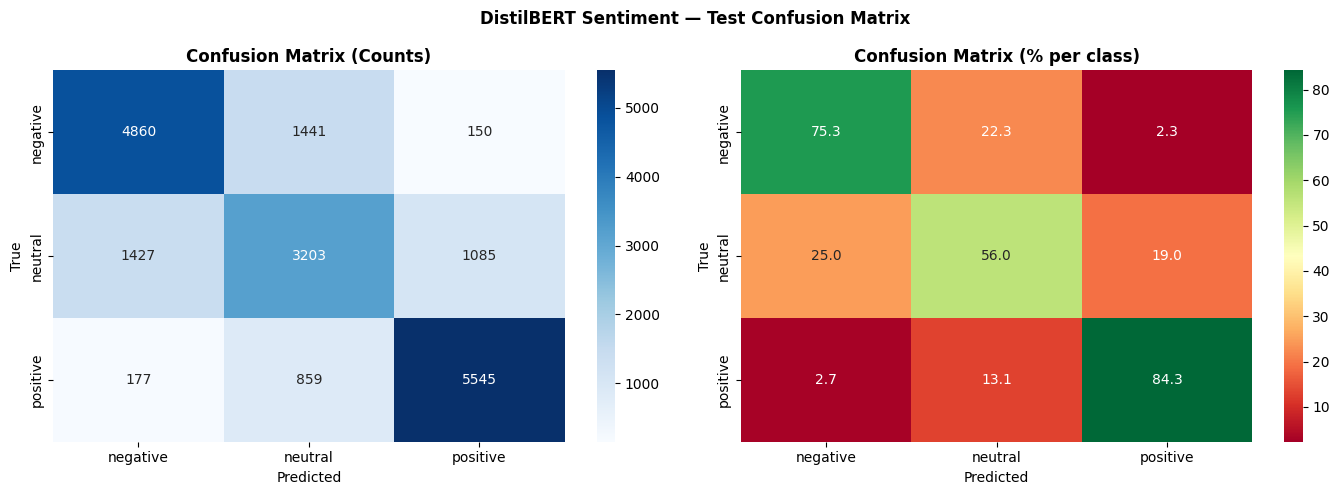

✅ Confusion matrix saved


In [13]:
# ── Confusion matrix
cm     = confusion_matrix(test_labels, test_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CFG['label_names'], yticklabels=CFG['label_names'])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[1],
            xticklabels=CFG['label_names'], yticklabels=CFG['label_names'])
axes[1].set_title('Confusion Matrix (% per class)', fontweight='bold')
axes[1].set_ylabel('True')
axes[1].set_xlabel('Predicted')

plt.suptitle('DistilBERT Sentiment — Test Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_confusion_matrix.png', dpi=150)
plt.show()
print('✅ Confusion matrix saved')

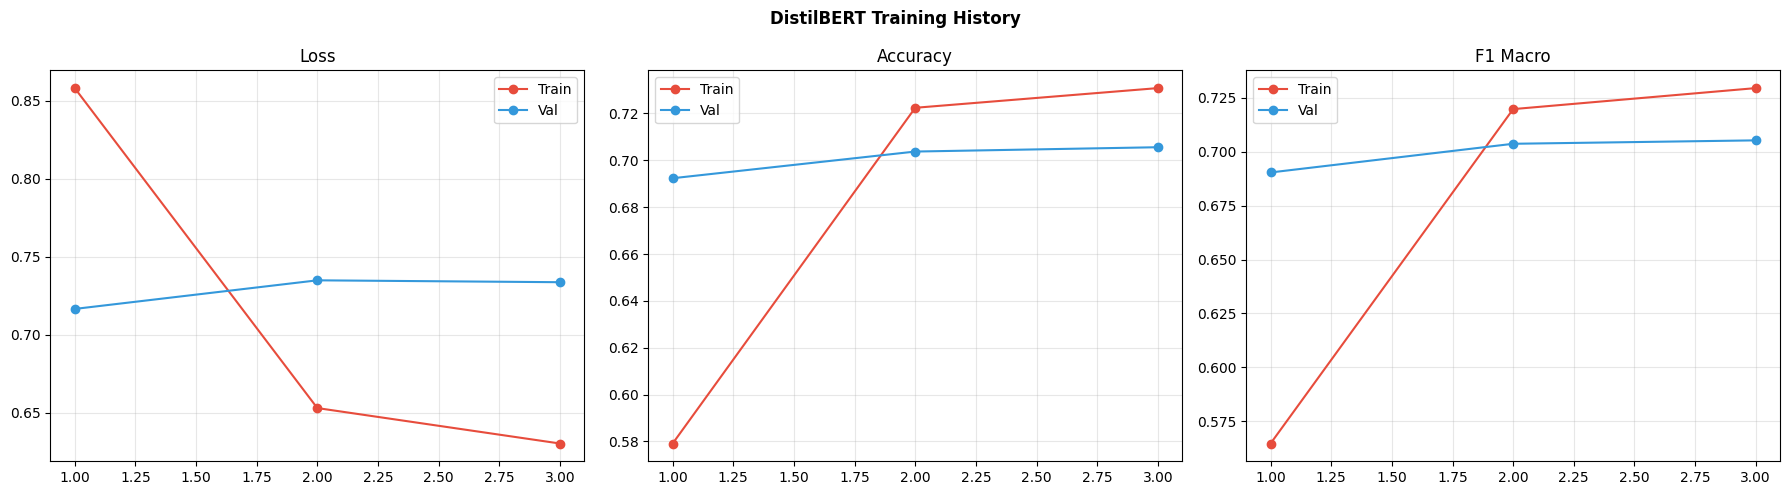


  nb-03 DistilBERT COMPLETE
  Best Epoch    : 3
  Val F1        : 0.7052
  Val Acc       : 0.7056
  Test F1       : 0.7179
  Test Acc      : 0.7259
  MLflow Run ID : c6bbfe640e354d3da48e8e09004fbfb6

 Saved → /kaggle/working/models/distilbert_sentiment_best.pt


In [14]:
# ── Training curves
epochs_range = list(range(1, len(history['train_loss']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DistilBERT Training History', fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], 'o-', color='#e74c3c', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'o-', color='#3498db', label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'],  'o-', color='#e74c3c', label='Train')
axes[1].plot(epochs_range, history['val_acc'],    'o-', color='#3498db', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['train_f1'],   'o-', color='#e74c3c', label='Train')
axes[2].plot(epochs_range, history['val_f1'],     'o-', color='#3498db', label='Val')
axes[2].set_title('F1 Macro'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '03_training_curves.png', dpi=150)
plt.show()

# ── Final summary
print('\n' + '='*55)
print('  nb-03 DistilBERT COMPLETE')
print('='*55)
print(f'  Best Epoch    : {best_epoch}')
print(f'  Val F1        : {best_val_f1:.4f}')
print(f'  Val Acc       : {best_val_acc:.4f}')
print(f'  Test F1       : {report_dict["macro avg"]["f1-score"]:.4f}')
print(f'  Test Acc      : {test_acc:.4f}')
print(f'  MLflow Run ID : {RUN_ID}')
print('='*55)
print(f'\n Saved → {MODEL_DIR}/distilbert_sentiment_best.pt')